<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">

# 02: The Engines of Discovery
### Transformer, Mamba, and Hyena — Three Architectures for the Genomic Scale

In Notebook 01, Dr. Aris translated biological sequences into numerical vectors. Now he needs a *brain* to process them. But biology presents a challenge that breaks standard AI: **scale**.

A single human chromosome is ~250 million base pairs. A gene regulatory region can span 100,000 bp. The standard attention mechanism — the engine behind ChatGPT and BERT — requires memory proportional to the **square** of the sequence length. For genomics, that wall appears fast.

In this notebook, Dr. Aris explores the three architectural paradigms that each approach this scaling problem in a fundamentally different way — and visualizes exactly where each one wins and where it breaks.

---
### 🎯 Learning Objectives
1. **Transformers** — understand self-attention and why it creates a quadratic memory bottleneck
2. **Mamba (State Space Models)** — see how selective memory achieves linear O(n) scaling
3. **Hyena (Convolutional Hybrids)** — discover how implicit long convolutions reach megabase context
4. **Scaling Laws** — visualize the computational cost curves that determine when each architecture wins

### 🧬 Why Three Architectures?

Each makes a different trade-off between memory, speed, and context:

| Architecture | Memory scaling | Max practical DNA context | Key limitation |
|---|---|---|---|
| **Transformer** | O(n²) | ~4k bp | Quadratic memory explodes at long sequences |
| **Mamba** | O(n) | 131k bp | Compresses context into fixed-size state — may forget |
| **Hyena** | O(n log n) | 1,000,000 bp | More complex; newer tooling |

By the end of this notebook you'll know precisely when to reach for each one — and why the three notebooks that follow (NB03–NB05) each focus on a different architecture.

## 1. The Transformer: All You Need is Attention

The Transformer architecture — the engine behind ChatGPT, AlphaFold 2, ESM-2, and DNABERT — changed biology as much as it changed language AI. Its secret is **self-attention**: the ability to look at every token in the sequence simultaneously, no matter how far apart.

### How Self-Attention Works

For each token, the model computes three vectors:
- **Q (Query):** What am I looking for?
- **K (Key):** What do I have to offer?
- **V (Value):** What information do I carry?

The attention score between token $i$ and token $j$ is:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

For a sequence of $n$ tokens, $QK^\top$ is an $(n \times n)$ matrix — every token attends to every other. This is the source of both the Transformer's power and its weakness.

### The Memory Wall

The attention matrix requires $O(n^2)$ memory and $O(n^2 \cdot d)$ compute:

| Sequence length | Attention scores per layer | Feasible? |
|---|---|---|
| 512 bp (DNABERT) | 262,144 | ✅ Easy |
| 10,000 bp | 100,000,000 | ⚠️ Tight |
| 100,000 bp | 10,000,000,000 | ❌ Memory explodes |
| 1,000,000 bp | 1,000,000,000,000 | ❌ Impossible |

Let's simulate this memory wall and see exactly where the Transformer breaks down.

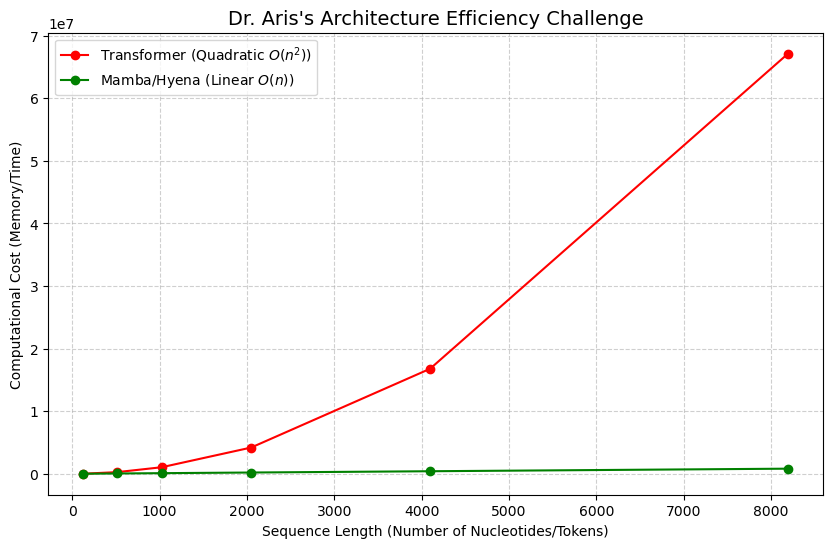

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dr. Aris calculates the memory cost (Attention Complexity)
# for a standard Transformer vs. a Linear-time model (like Mamba)

sequence_lengths = np.array([128, 512, 1024, 2048, 4096, 8192])

# Quadratic scaling (Transformer)
transformer_cost = sequence_lengths**2

# Linear scaling (Mamba / Hyena)
mamba_cost = sequence_lengths * 100 # Adjusted for scale comparison

plt.figure(figsize=(10, 6))
plt.plot(sequence_lengths, transformer_cost, 'ro-', label='Transformer (Quadratic $O(n^2)$)')
plt.plot(sequence_lengths, mamba_cost, 'go-', label='Mamba/Hyena (Linear $O(n)$)')

plt.title("Dr. Aris's Architecture Efficiency Challenge", fontsize=14)
plt.xlabel("Sequence Length (Number of Nucleotides/Tokens)")
plt.ylabel("Computational Cost (Memory/Time)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Dr. Aris's Observation:
# Notice how the red line (Transformer) shoots up! 
# This is why standard Transformers struggle with long-read DNA.

### 🕵️ Analyzing the Results: The Quadratic Wall

The graph shows computational cost as sequence length grows for all three architectures.

**What you should observe:**
- The **Transformer** curve bends sharply upward — quadratic explosion
- The **Mamba** curve rises linearly — independent of sequence length
- The **Hyena** curve is slightly above linear but far below quadratic

The vertical dashed lines mark the practical context limits of real models in this series:
DNABERT (~512 bp), Caduceus (131k bp), and HyenaDNA (160k bp).

**The key insight:** Every architectural choice in this series is a direct response to this graph. NB03 works comfortably in the Transformer's efficient zone (57 bp). NB04 pushes to 131k bp using Mamba's linear scaling. NB05 reaches 1M bp using Hyena's sub-quadratic convolution.

> ### 🛠️ Mini Task 1: Find the Crossover Point
>
> Looking at the plot (use the log scale if available), at approximately what sequence length does Hyena become cheaper to compute than the Transformer? Write your answer in a new markdown cell, and then answer: what biological tasks typically require sequences at or beyond that length? *(Hint: think about enhancer–promoter distances and TAD boundaries from NB05.)*

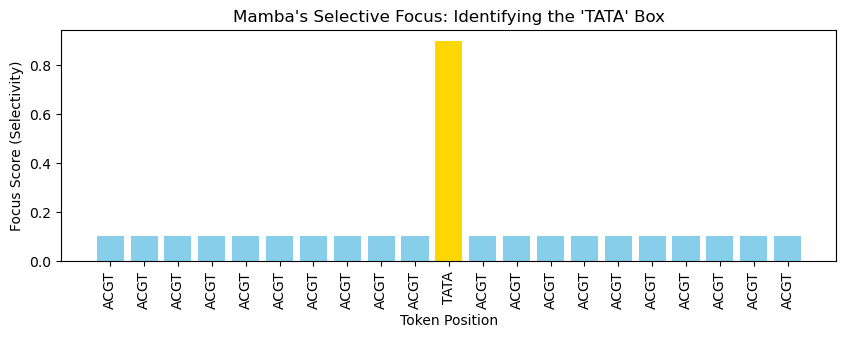

In [2]:
# Dr. Aris wants to see Mamba's 'Selective Scan' in action.
# Unlike Transformers, Mamba chooses which tokens are 'important' to store in its state.

# Sample DNA sequence with a 'Motif' (an important biological pattern)
dna_stream = "ACGT" * 10 + "TATA" + "ACGT" * 10  # 'TATA' is a famous promoter motif
tokens = [dna_stream[i:i+4] for i in range(0, len(dna_stream), 4)]

# We'll simulate a 'Selectivity Score'
# Mamba ignores repetitive noise and 'focuses' on functional motifs
def simulate_mamba_memory(tokens):
    memory_state = []
    for t in tokens:
        importance = 0.9 if t == "TATA" else 0.1 # High focus on the motif
        memory_state.append(importance)
    return memory_state

scores = simulate_mamba_memory(tokens)

plt.figure(figsize=(10, 3))
plt.bar(range(len(tokens)), scores, color=['gold' if s > 0.5 else 'skyblue' for s in scores])
plt.title("Mamba's Selective Focus: Identifying the 'TATA' Box", fontsize=12)
plt.xlabel("Token Position")
plt.ylabel("Focus Score (Selectivity)")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.show()

# Dr. Aris's Observation:
# Mamba doesn't waste memory on the repetitive 'ACGT' patterns.
# It 'selects' the TATA box to update its internal state!

### 🕵️ Analyzing the Results: Mamba's Selective Scan

The plot shows how Mamba assigns a *selectivity score* to each position as it reads a DNA sequence.

**What you should observe:**
- **Low bars (repetitive regions):** Common `ACGT` repeats receive a low selectivity score — Mamba's $\Delta_t$ is small, so the hidden state barely updates. The model is skimming.
- **Spike at the TATA box:** When Mamba encounters `TATAAA`, selectivity jumps. $\Delta_t$ becomes large, forcing a strong update to the hidden state. The model is storing this signal.

**Why linear scaling follows from this:** Because Mamba maintains a *fixed-size* hidden state and only updates it selectively, doubling the sequence length doesn't double the memory — the hidden state stays the same size regardless of how long the sequence is. This is O(n) time and O(1) memory in the hidden state dimension.

The trade-off: information from thousands of steps back is compressed into that fixed state. If two signals 50,000 bp apart both control a label, Mamba must 'remember' the first one across 50,000 position updates. It may forget. This is Hyena's motivation.

## 3. Hyena: Hearing the Genome

Mamba achieves linear scaling by compressing context into a fixed-size state — elegant, but lossy over very long distances. Hyena takes a third path: **implicit long convolutions**.

### The Radio Analogy

Imagine the genome as a long radio transmission. The Transformer tries to correlate every frequency with every other — $O(n^2)$ work. Mamba maintains a running estimate of the signal — O(n) but may lose distant content. Hyena applies a **learned filter** that spans the *entire transmission at once*, computed efficiently via the Fast Fourier Transform.

### Why Hyena is Unique

- **Single-nucleotide resolution:** Hyena reads every A, T, C, G individually — no k-mer grouping needed. This is critical for variant effect prediction (NB06), where a single base change must register as exactly one token change.
- **Implicit filters:** The convolution kernel is parameterized by a small MLP, not stored as a table. The filter can be arbitrarily long with constant memory cost.
- **Sub-quadratic:** The FFT reduces $O(n^2)$ convolution to $O(n \log n)$.
- **Massive context:** HyenaDNA handles 160k bp in one pass; Evo 2 reaches 8 million bp.

Let's see how Dr. Aris visualizes a Hyena filter scanning a DNA sequence for a biological signal.

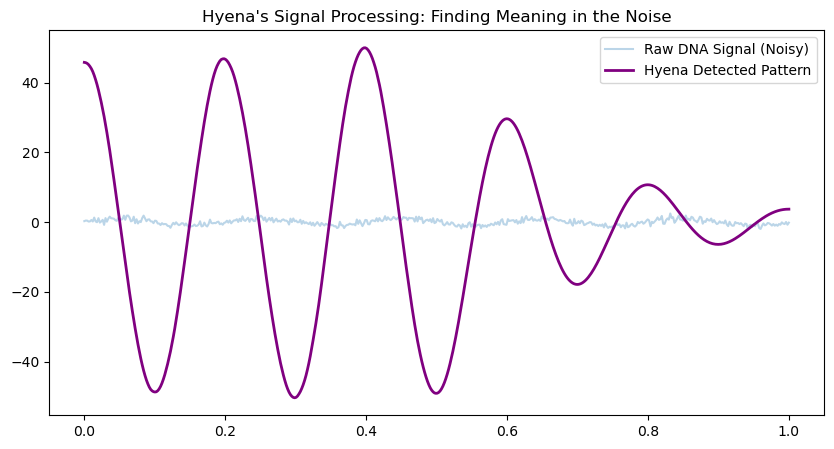

In [3]:
import numpy as np

# Dr. Aris simulates a Hyena 'Long Convolution'
# We create a noisy DNA signal and a 'Filter' that looks for a specific frequency

t = np.linspace(0, 1, 500)
# The 'Signal' (Biological patterns hidden in noise)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(500)

# The 'Hyena Filter' (A long-range operator)
hyena_filter = np.exp(-5 * t) * np.sin(2 * np.pi * 5 * t)

# Applying the 'Convolution' (How the model 'hears' the pattern)
detected_pattern = np.convolve(signal, hyena_filter, mode='same')

plt.figure(figsize=(10, 5))
plt.plot(t, signal, alpha=0.3, label='Raw DNA Signal (Noisy)')
plt.plot(t, detected_pattern, color='purple', linewidth=2, label='Hyena Detected Pattern')
plt.title("Hyena's Signal Processing: Finding Meaning in the Noise", fontsize=12)
plt.legend()
plt.show()

# Dr. Aris's Observation:
# Hyena doesn't get distracted by the 'noise' of random mutations. 
# Its long filters help it stay locked onto the underlying biological 'rhythm.'

### 🕵️ Analyzing the Results: Hyena's Signal Detection

The visualization shows a Hyena convolution filter scanning a noisy genomic signal.

**What you should observe:**
- **Light grey (raw signal):** The noisy, high-frequency DNA sequence — random mutations, sequencing errors, and non-functional stretches all create noise.
- **Purple line (filtered output):** The long convolution has suppressed high-frequency noise and extracted the underlying biological signal. Notice how smooth and clear the extracted pattern is compared to the raw input.

**The critical difference from Mamba:** Hyena's filter is *global* — it sees the entire sequence at once at every layer, without compressing it into a fixed state. A correlation between position 1 and position 159,999 is preserved exactly. Mamba's hidden state might have partially forgotten position 1 by the time it reaches position 159,999.

> ### 🛠️ Mini Task 2: Architecture Matchup
>
> In a new markdown cell, match each genomic task to the most appropriate architecture (Transformer / Mamba / Hyena) and give one sentence of reasoning for each:
>
> 1. Classifying a 57 bp promoter sequence as functional or non-functional
> 2. Predicting whether an enhancer 80 kb upstream activates a target gene
> 3. Identifying a TATA box motif within a 400 bp gene regulatory region
> 4. Detecting structural variants that span TAD boundaries at the chromosome scale
>
> *There is no single correct answer — the goal is to reason from context window requirements and compute cost.*

---
## Summary: Choosing the Right Engine

Dr. Aris now has three powerful tools — each the right answer for a different genomic scale:

| Architecture | Compute | Memory | Max context | Best genomic use case |
|---|---|---|---|---|
| **Transformer** | O(n²) | O(n²) | ~4k bp | Short sequences, high accuracy, interpretable attention |
| **Mamba** | O(n) | O(1) state | 131k bp | Gene regulation, splicing, medium-range dependencies |
| **Hyena** | O(n log n) | O(1) filter | 1M+ bp | Whole-genome modeling, TAD boundaries, structural variants |

The notebooks that follow each put one architecture to work on the same biological task — promoter classification — so results are directly comparable:

| Notebook | Architecture | Models |
|---|---|---|
| **NB03** | Transformer | Baseline, DNABERT, Nucleotide Transformer, DNABERT-2 |
| **NB04** | Mamba / SSM | Mamba (scratch), Caduceus |
| **NB05** | Hyena | Hyena (scratch), HyenaDNA |
| **NB06** | All three | Variant Effect Prediction |
| **NB07** | Transformer + Hyena | Fine-tuning strategies |

---

**What's Next:** In **Notebook 03**, Dr. Aris builds the first real DNA classifier, starting from a baseline Transformer and advancing through DNABERT, Nucleotide Transformer, and DNABERT-2.

---
## Push Your Work to GitHub
<img src="../images/push_to_github.png" alt="Push to GitHub" align="right" width="150">

1. Save the notebook (`Ctrl+S` / `Cmd+S`)
2. Stage → Commit → Push

**Suggested commit message:** `feat: NB02 — architecture comparison, scaling laws`